# Projeto 2 - Previsão do desligamento de funcionários

## Dicionário de dados

* __Employee ID__: Um identificador exclusivo atribuido a cada funcionário  
* __Age__: A idade do funcionário, variando de 18 a 60 anos.  
* __Gender__: O gênero do funcionário.  
* __Years at Company__: O tempo que o funcionário está na empresa.  
* __Job Role__: O departamento ou função que o funcionário trabalha, codificado em categorias como Finanças, Saúde, Tecnologia, Educação e Mídia.
* __Monthly Income__: O salário mensal do funcionário em dólar.  
* __Work-Life Balance__: O equilibrio percebido do funcionário entre trabalho e vida pessoal (Ruim, Abaixo da Média, Bom, Excelente).  
* __Job Satisfaction__: A satisfação do funcionário com seu trabalho: (Muito baixo, Baixo, Médio, Alto)  
* __Performance Rating__: A classificação de desempenho do funcionário: (Baixo, Abaixo da Média, Médio, Alto)  
* __Number of Promotions__: O número total de promoções que o funcionário recebeu.  
* __Overtime__: Se o funcionário faz hora extra.  
* __Distance from Home__: A distancia entre a casa do funcionário e o local de trabalho, em milhas.  
* __Education Level__: O nível de educação mais alto atingido pelo funcionário: (Ensino médio, diploma de associado, bacharelado, mestrado e doutorado).  
* __Marital Status__: O estado civil do funcionário: (Divorciado, casado, solteiro).  
* __Number of Dependents__: Número de dependentes do funcionário.  
* __Job Level__: O nível do cargo do funcionário: (Iniciante, Médio, Sênior).  
* __Company Size__: O tamanho da empresa para à qual o funcionário trabalha: (Pequeno, médio, grande).  
* __Company Tenure__: O número total de anos que funcionário trabalha no setor.  
* __Remote Work__: Se o funcionário trabalha e modalidade remota: (Sim ou Não).  
* __Leadership Opportunities__: Se o funcionário tem oportunidades de liderança: (Sim ou Não).  
* __Innovation Opportunities__: Se o funcionário tem oportunidades de inovação: (Sim ou Não).  
* __Company Reputation__: A percepção do funcionário sobre a reputação da empresa: (Muito ruim, Ruim, Bom Excelente).
* __Employee Recognition__: O nível de reconhecimento do funcionário na empresa.  
* __Attrition__: Se o funcionário saiu da empresa, codificado como 0 (permaneceu) e 1 (saiu).

## Passo 1 - Definição do Problema de Negócio / Objetivo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import seaborn as sns

# Ajuste de hiperparâmetros e separação entre treino e teste
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV

# Técnicas para construir o modelo de previsão
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Pré-processamento / Normalização dos dados
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, OneHotEncoder

# Balanceamento da classe "target" para prevenir distorções
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Métricas para validação de performance do modelo
from sklearn.metrics import accuracy_score, classification_report

import os
import warnings
import joblib
from datetime import datetime

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore')

In [2]:
print(f'Data inicio: {str(datetime.now().strftime('%Y-%m-%d'))}')

Data inicio: 2026-03-23


In [3]:
FILE_NAME = 'dados_historicos.csv'

if os.path.exists(FILE_NAME):
    try:
        components = np.array([os.getcwd(), FILE_NAME])
        path = os.path.join(*np.concatenate(components.reshape(-1, 1)))
    except Exception as e:
        raise NotADirectoryError(f'Folder is not a directory: {e}')

df = pd.read_csv(path, encoding='utf-8', na_filter=True, verbose=0)
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390.0,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534.0,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159.0,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,NaN,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821.0,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [4]:
# Verificando valores nulos

df.isna().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              7
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
Attrition                   0
dtype: int64

In [5]:
df.shape

(59598, 24)

### Passo 2 - Análise Exploratória (EDA)

In [6]:
# Analisar os valores unicos para cada variável
# Nesse caso é importante para saber quais colunas serão tratadas como categóricas

unique_values = []
for c in df.columns[0:24].tolist():
    print(c, ':', len(df[c].astype(str).value_counts()))
    unique_values.append(df[c].astype(str).value_counts())

Employee ID : 59598
Age : 42
Gender : 2
Years at Company : 51
Job Role : 5
Monthly Income : 9570
Work-Life Balance : 4
Job Satisfaction : 4
Performance Rating : 4
Number of Promotions : 5
Overtime : 2
Distance from Home : 99
Education Level : 5
Marital Status : 3
Number of Dependents : 7
Job Level : 3
Company Size : 3
Company Tenure : 127
Remote Work : 2
Leadership Opportunities : 2
Innovation Opportunities : 2
Company Reputation : 4
Employee Recognition : 4
Attrition : 2


In [7]:
# Conferindo os valores mínimos e máximos referente à cada funcionário

attr_int = [
    cname for cname in df.select_dtypes(include=['int']).columns
        .to_numpy()
        .ravel()
]

df_agg: pd.DataFrame = (
    df.agg(dict(map(lambda col: (col, ['min', 'max']), sorted(attr_int))))
)

df_agg

,Age,Company Tenure,Distance from Home,Employee ID,Number of Dependents,Number of Promotions,Years at Company
min,18,2,1,1,0,0,1
max,59,128,99,74498,6,4,51


In [8]:
# Identificar casos que a quantidade de anos de trabalho é superior a idade do funcionário

df.loc[df['Company Tenure'] > df['Age']].iloc[0:5]

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390.0,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
2,30257,24,Female,10,Healthcare,8159.0,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,NaN,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821.0,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
5,24368,38,Female,3,Technology,9977.0,Fair,High,Below Average,3,...,0,Mid,Medium,47,No,No,Yes,Fair,High,Left


In [9]:
# Verificando a quantidade de casos que existem ao problema citado acima

df_count = df[df['Company Tenure'] > df['Age']]
print(f'Total de casos => {df_count.shape[0]}')

Total de casos => 42283


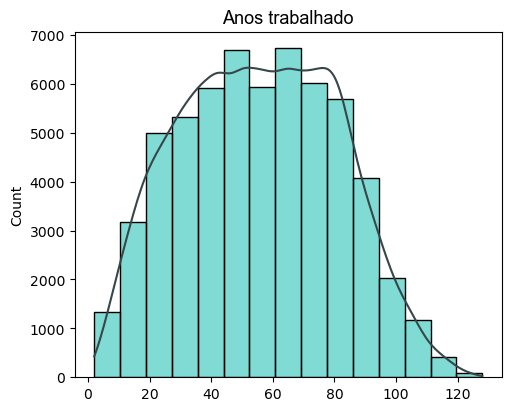

In [10]:
# Analisar a distribuição dos dados da mesma variável anteriormente
dict_font = {
    'fontsize': 13,
    'fontfamily': 'Arial',
    'color': 'black'
}

fig, ax = plt.subplots(figsize=(5, 4), layout='constrained')
ax = sns.histplot(
    df['Company Tenure'].values, 
    bins=15, 
    color='#01B8AA', 
    kde=True, 
).set_title(f'Anos trabalhado', fontdict=dict_font)

plt.gca().lines[0].set_color('#374649')

plt.show()

In [11]:
# Realizar um filtro, calculando (Idade - Anos na Empresa) e considerando o que for menor de 18 anos de idade

df.loc[(df['Age'] - df['Years at Company'] < 18)].head(10)

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390.0,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
2,30257,24,Female,10,Healthcare,8159.0,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
4,65026,56,Male,41,Education,4821.0,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed
8,32714,57,Male,44,Education,3773.0,Good,Medium,High,1,...,4,Entry,Medium,75,No,No,No,Fair,Medium,Stayed
12,21896,47,Female,38,Technology,NaN,Fair,Very High,High,1,...,0,Entry,Small,68,No,No,No,Good,Low,Left
13,28098,31,Male,22,Healthcare,8090.0,Fair,Medium,High,4,...,2,Mid,Small,84,No,No,No,Good,Medium,Stayed
14,22068,40,Female,30,Technology,6350.0,Good,High,Average,0,...,0,Senior,Large,96,No,No,No,Good,High,Stayed
16,55668,19,Female,9,Technology,8242.0,Excellent,Medium,Average,2,...,3,Mid,Small,63,No,No,No,Fair,High,Left
18,17034,49,Female,37,Media,6252.0,Fair,High,High,2,...,4,Senior,Medium,70,No,No,No,Good,High,Stayed
20,17209,51,Female,41,Finance,8733.0,Good,High,Average,2,...,3,Mid,Small,72,No,No,No,Good,High,Stayed


In [12]:
# Carregando as variaveis numericas
num_vars = []
for n in df.columns[0:24].tolist():
    if df.dtypes[n] == 'int64' or df.dtypes[n] == 'float64':
        num_vars.append(n)

In [13]:
# Carregando as variaveis categoricas
cat_vars = []
for c in df.columns[0:24].tolist():
    if df.dtypes[c] == 'object' or df.dtypes[c] == 'category':
        cat_vars.append(c)

In [14]:
# Checando o total de cada tipagem

print(f'Total de variáveis numéricas: {len(num_vars)}')
print(f'Total de variáveis categóricas: {len(cat_vars)}')

Total de variáveis numéricas: 8
Total de variáveis categóricas: 16


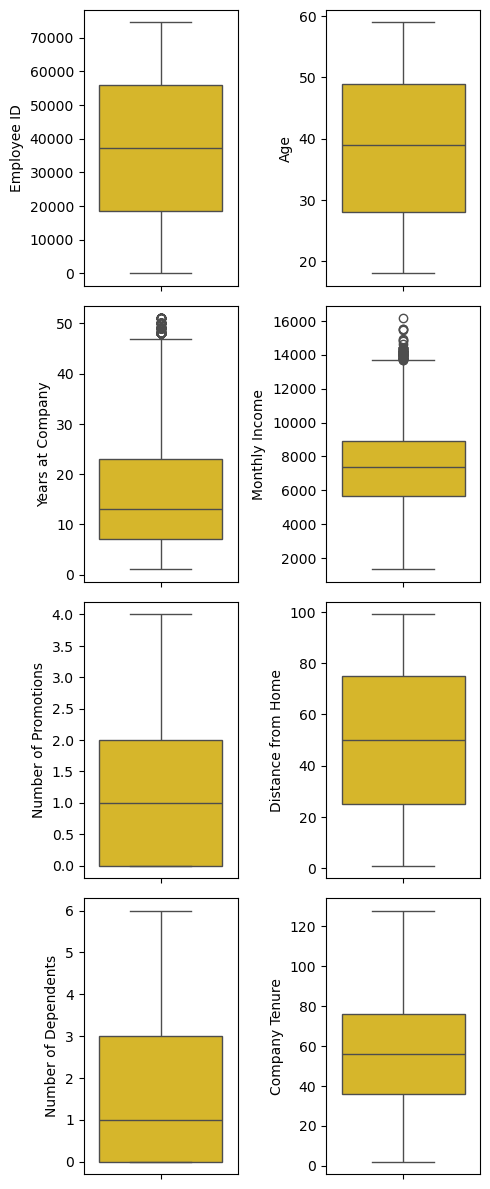

In [15]:
# Boxplot para identificar "possiveis outliers" em variaveis numericas

plt.rcParams['figure.figsize'] = [5, 12]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(4, 2)

rows = 0
cols = 0
for i in num_vars:
    sns.boxplot(data=df, y=i, ax=axes[rows][cols], color='#F2C80F')
    cols += 1
    if cols == 2:
        rows += 1
        cols = 0

plt.show()

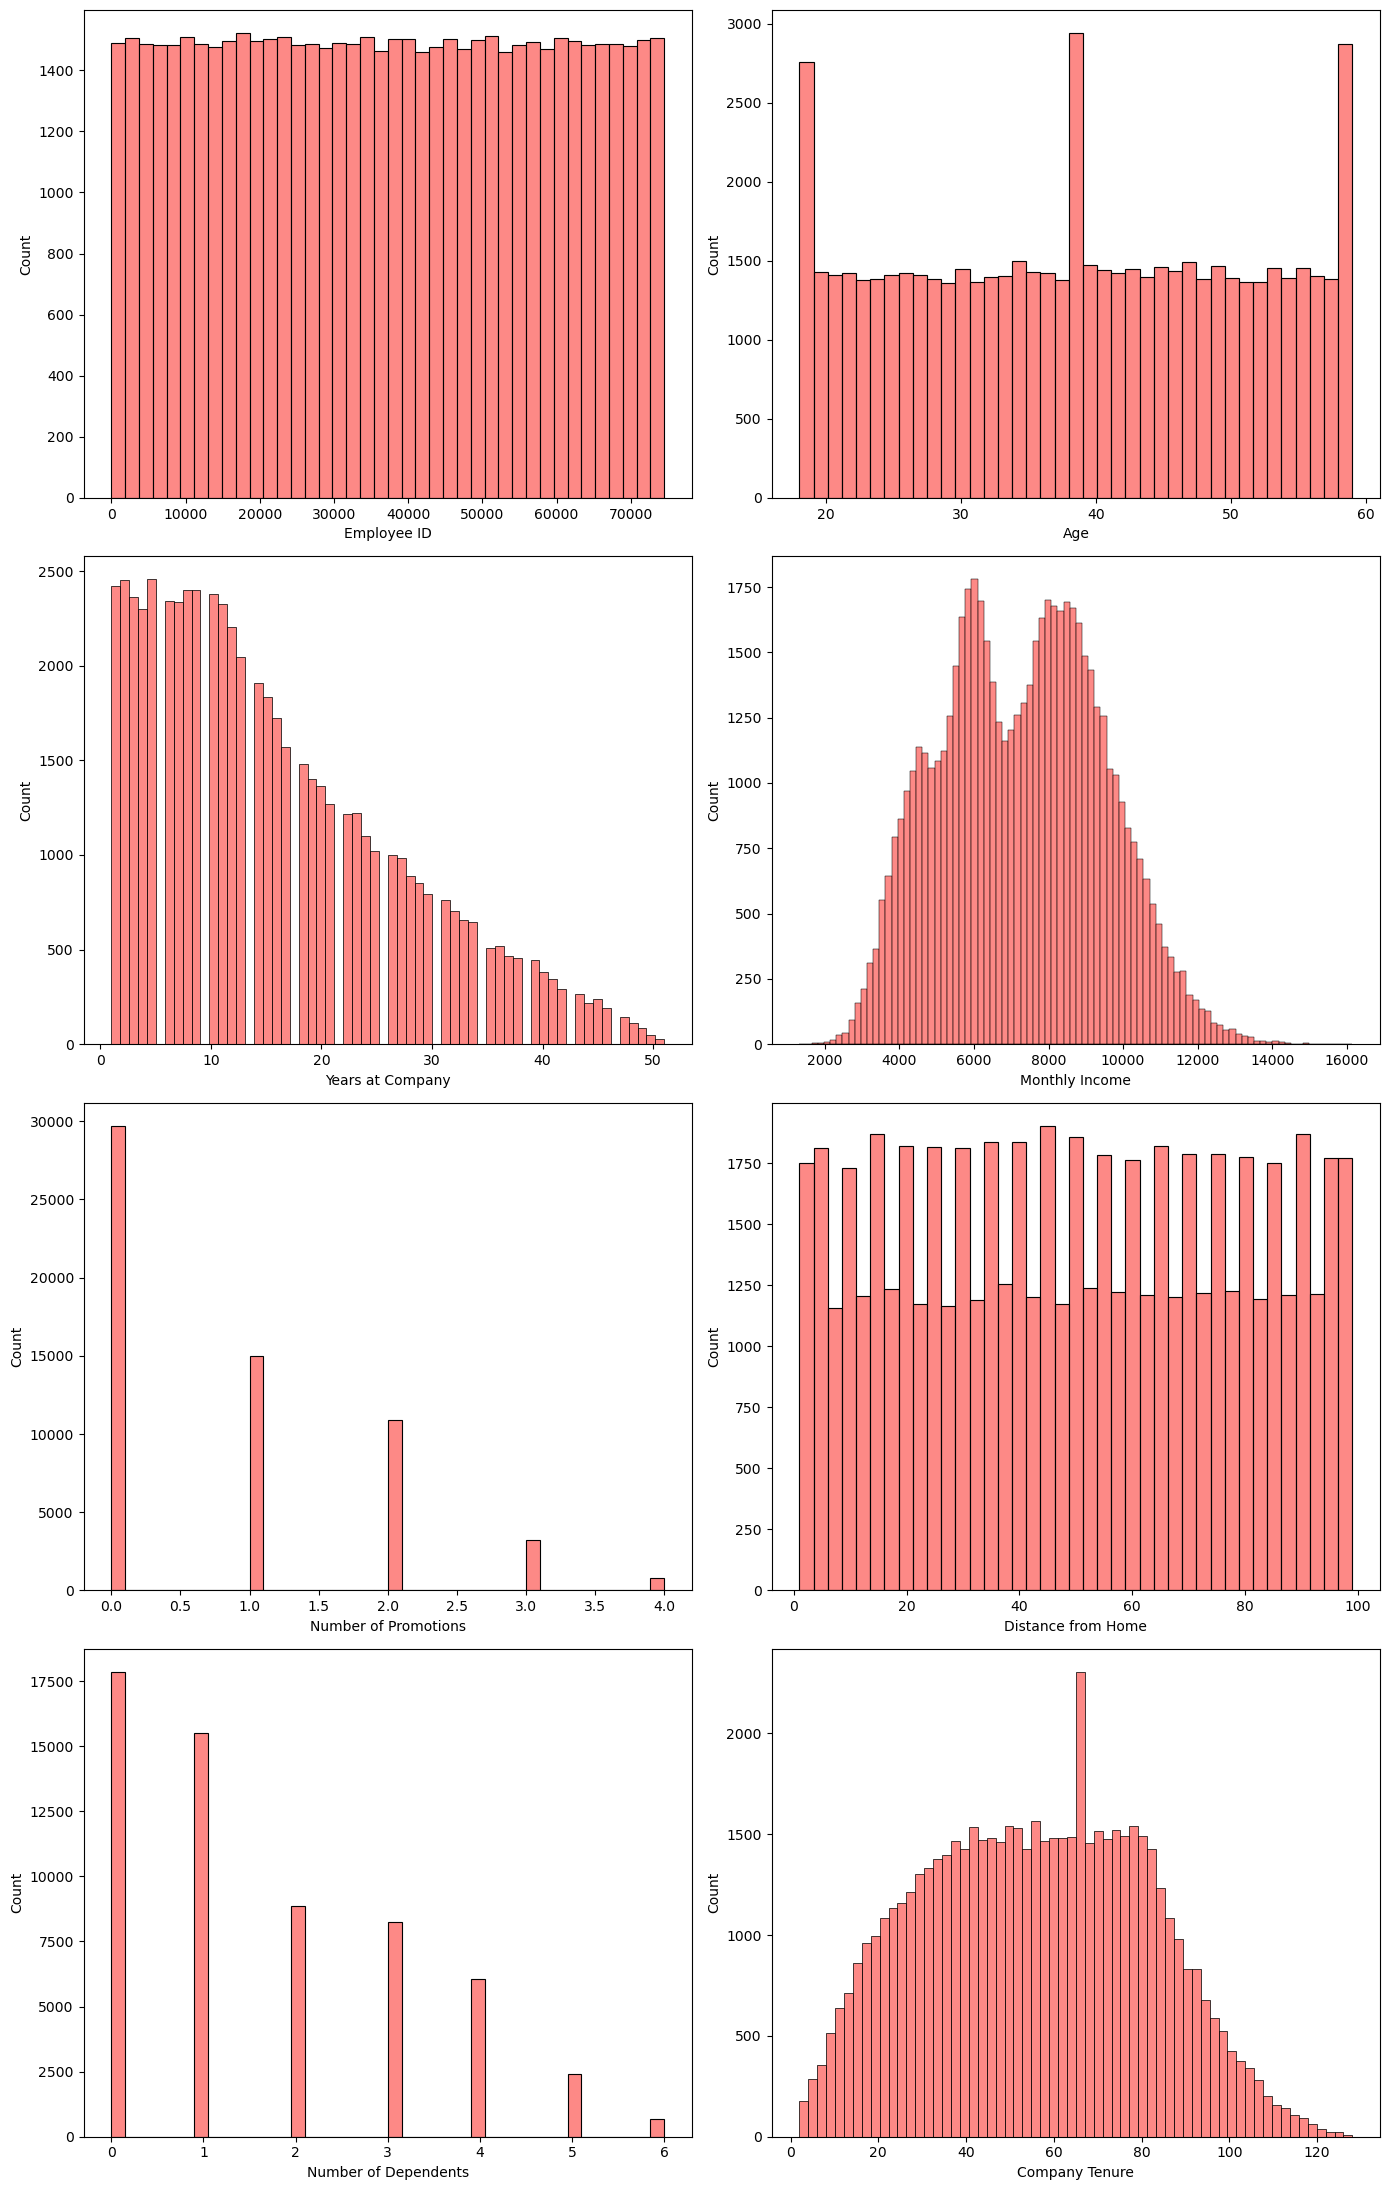

In [16]:
# Histograma para visualizar a "distribuição" em variaveis numericas

plt.rcParams['figure.figsize'] = [14, 22]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(4, 2)

rows = 0
cols = 0
for i in num_vars:
    sns.histplot(data=df, x=i, ax=axes[rows][cols], color='#FD625E')
    cols += 1
    if cols == 2:
        rows += 1
        cols = 0

plt.show()

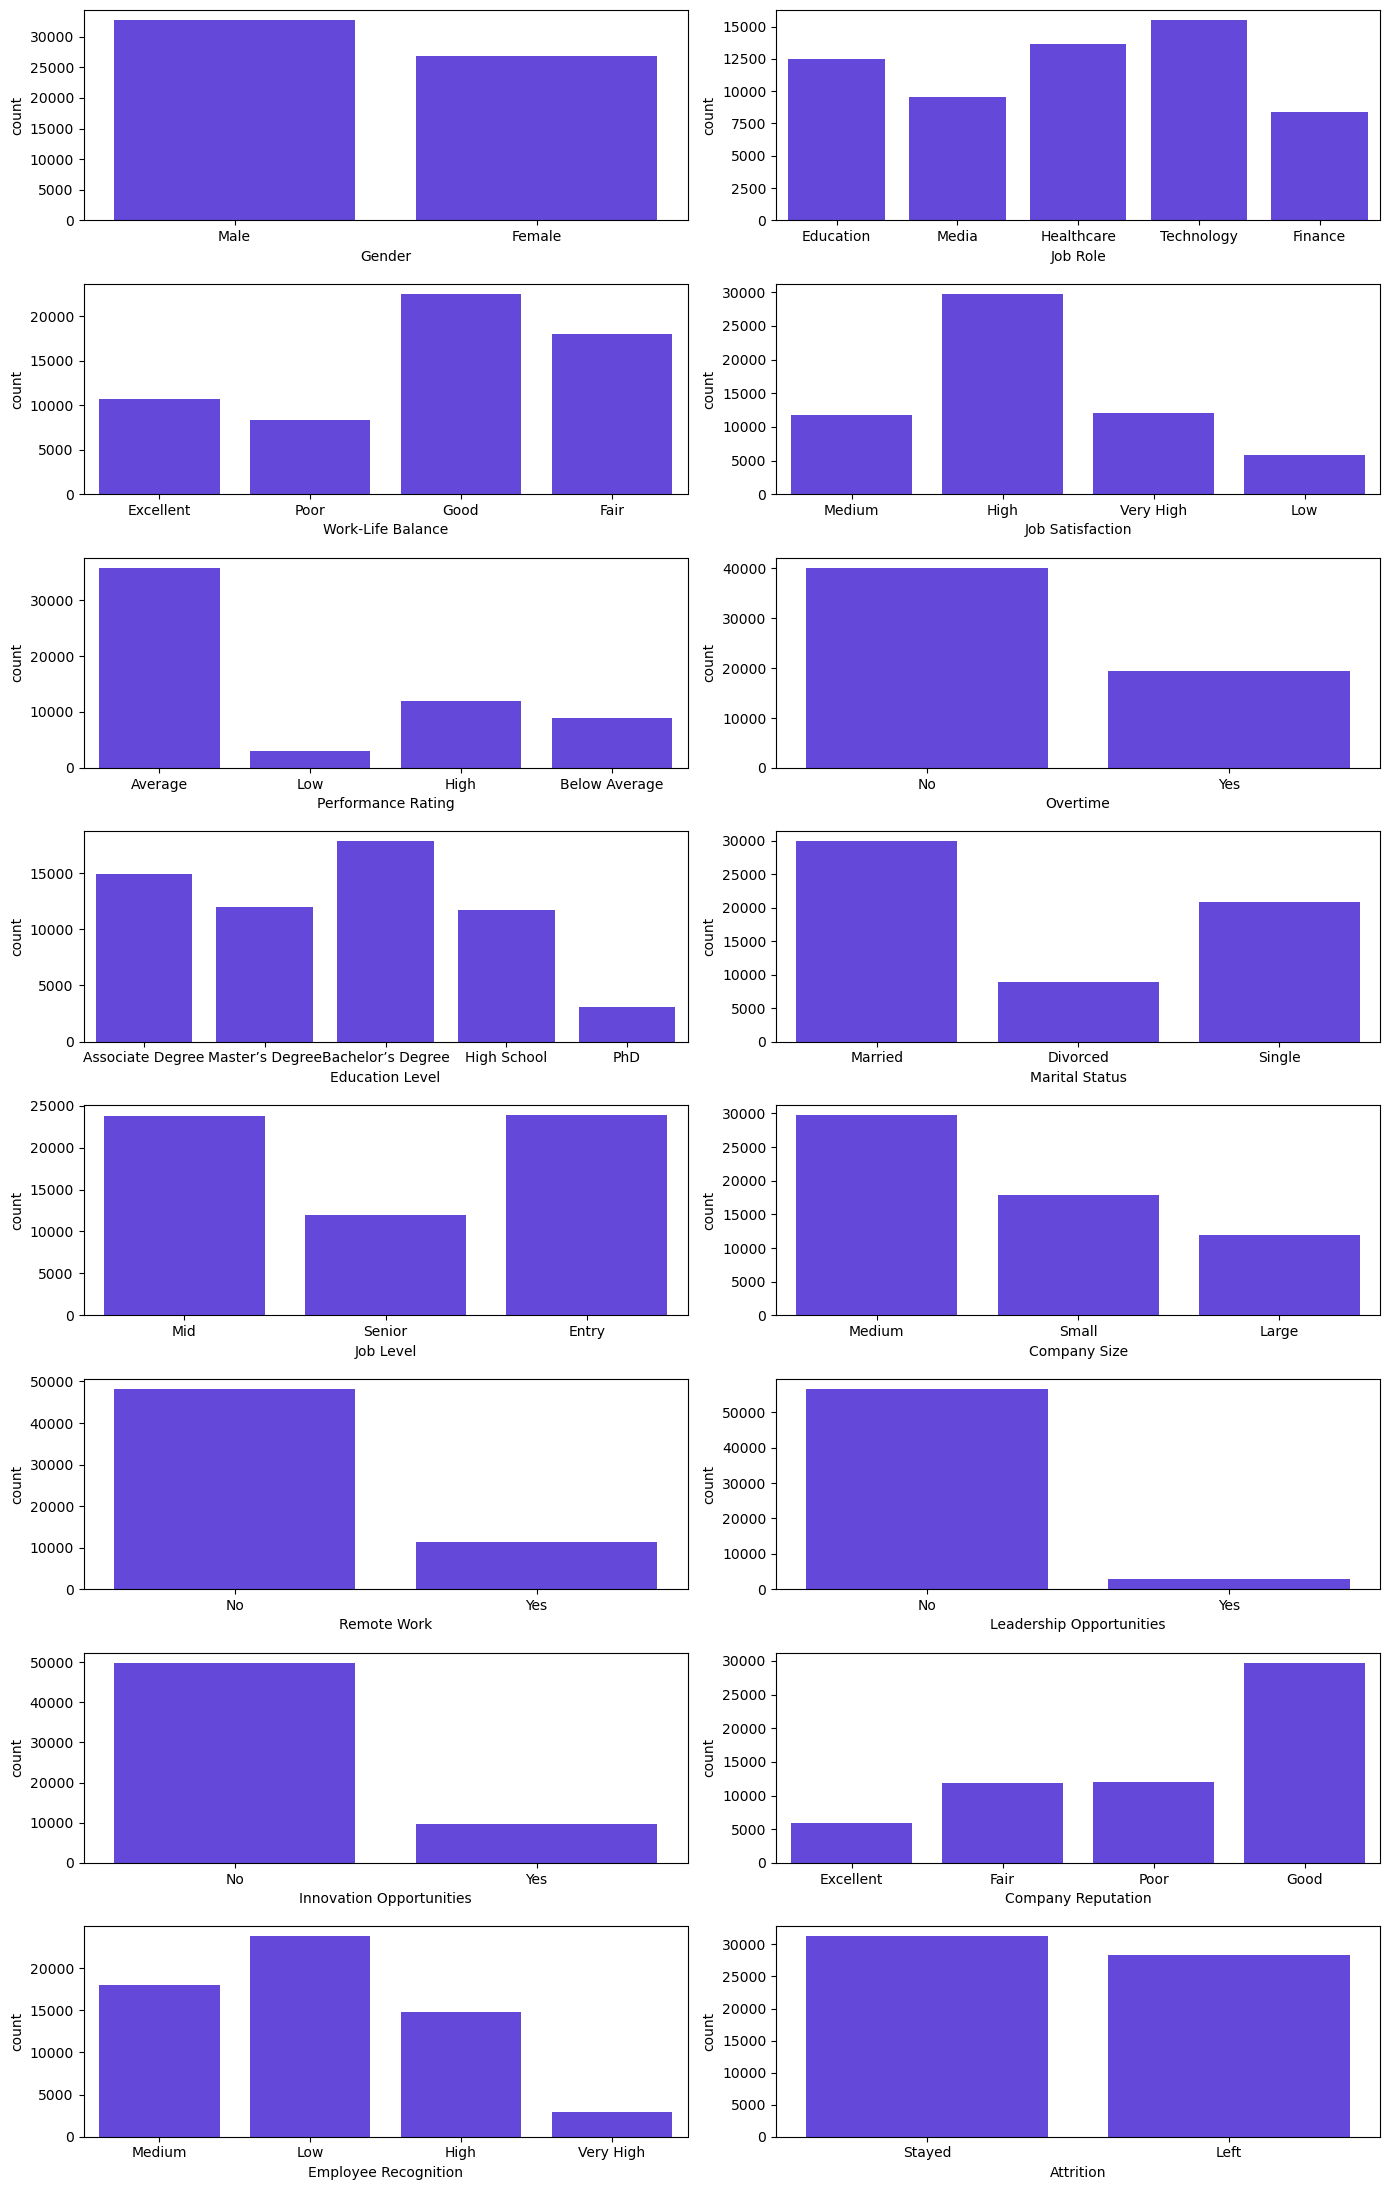

In [17]:
# Countplot para mostrar a "frequencia" em variaveis categoricas

plt.rcParams['figure.figsize'] = [14, 22]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(8, 2)

rows = 0
cols = 0
for i in cat_vars:
    sns.countplot(data=df, x=i, ax=axes[rows][cols], color='#5330f2')
    cols += 1
    if cols == 2:
        rows += 1
        cols = 0

plt.show()

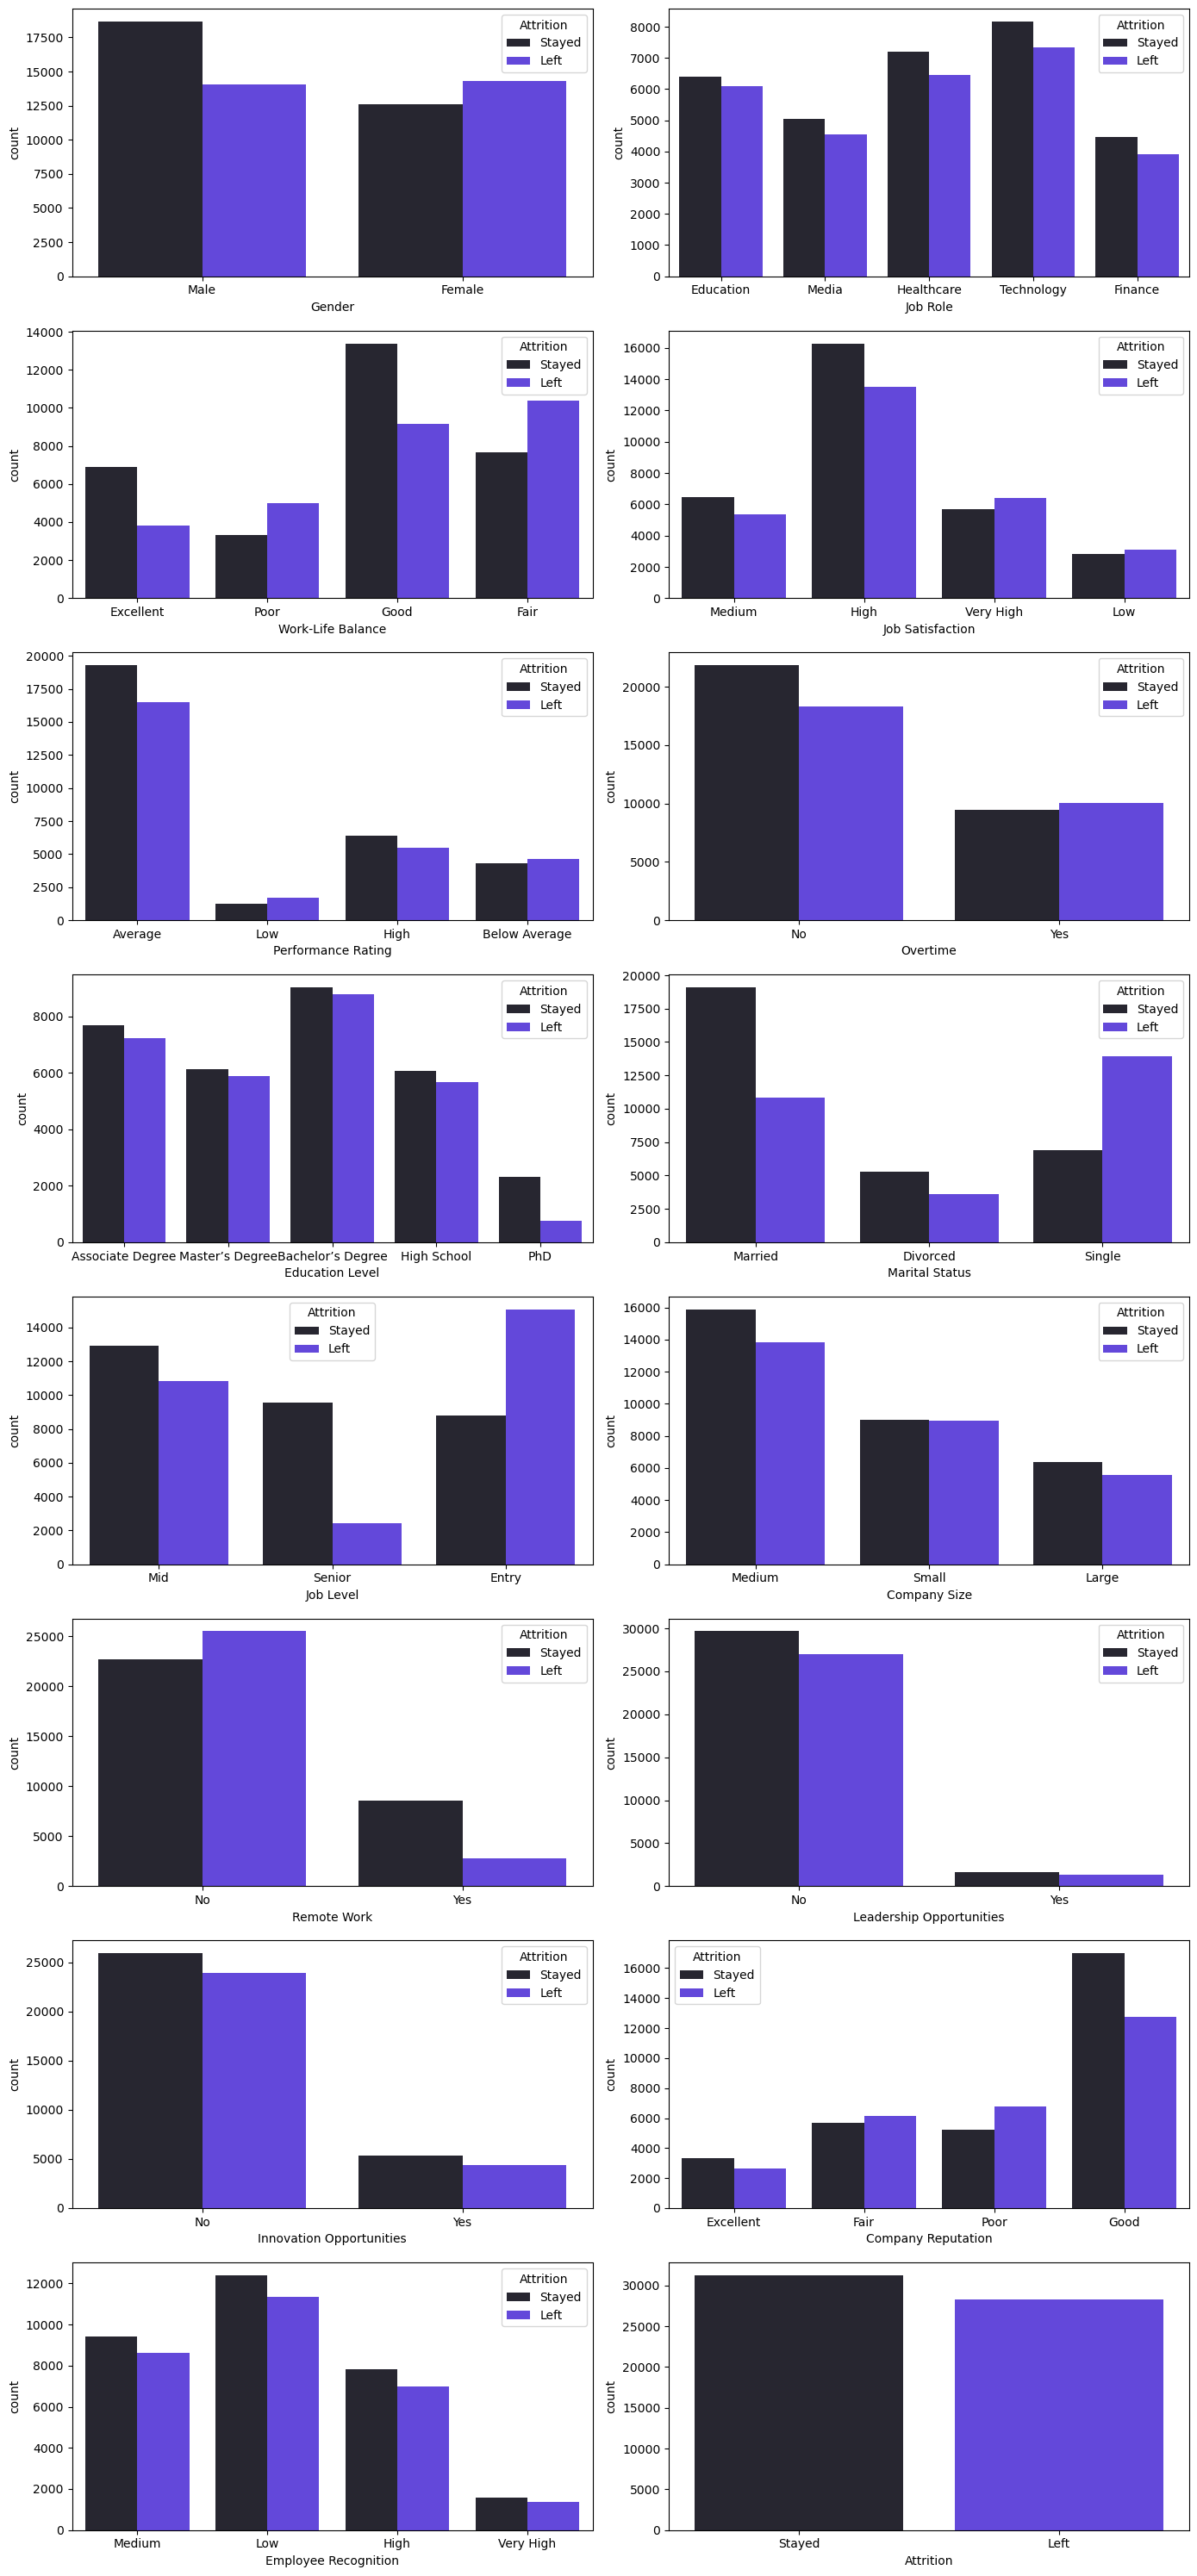

In [18]:
# Countplot para entender a "frequencia" em variaveis categoricas em relação à variável target

plt.rcParams['figure.figsize'] = [14, 30]
plt.rcParams['figure.autolayout'] = True

fig, axes = plt.subplots(8, 2)

rows = 0
cols = 0
for i in cat_vars:
    sns.countplot(data=df, x=i, ax=axes[rows][cols], color='#5330f2', hue='Attrition')
    cols += 1
    if cols == 2:
        rows += 1
        cols = 0

plt.show()

In [19]:
# Validando a discrepancia do atributo "Attrition -> (Situação)" para balanceamento
# Como foi constatado acima, o gráfico mostra que a variável está ligeiramente desbalanceada

df.groupby(['Attrition']).size()

Attrition
Left      28338
Stayed    31260
dtype: int64

### Passo 3 - Pré-processamento e tratamento dos dados

> Nesta etapa será realizada algumas tratativas necessárias para construir os modelos

1. A variável **Employee ID** será dispensada, pois trata-se somente da identificação dos funcionários
2. A variável **Monthly Income** possui valores nulos, portanto optei em preencher com a mediana por ser uma medida robusta.
3. Será criado uma coluna _Income_Range_ com base na variável **Monthly Income**.
4. A variável **Company Tenure** será excluída, por apresentar inconsistências, conforme validado no processo de análise exploratória.
5. A variável **Years at Company**, cujo a subtração com a idade for inferior a 18 anos, será definido como **1**.
6. A variável **Attrition** será codificada em classe binária: 0 = (Stayed - permaneceu) / 1 = (Left - saiu).
7. A variável **Attrition** será alterada para o tipo **category**.
8. O **OrdinalEncoder** será usado para os atributos do tipo object (Categorias Ordinais).
9. O **OneHotEncoder** será usado para os atributos do tipo object (Categorias Nominais).
10. Separar as variáveis preditoras da variável alvo.
11. A variável **Attrition** que é TARGET, será balanceada.
12. Dividir os dados em treino e teste.
13. Realizar a normalização dos dados.

In [20]:
# 1. Removendo o ID do funcionário
df.drop(columns=['Employee ID'], axis=1, inplace=True)

In [21]:
# 2. Substituindo os valores nulos pela mediana na variável "Monthly Income"
median = df['Monthly Income'].median()
df['Monthly Income'] = df['Monthly Income'].fillna(median)

In [22]:
# 3. Criar faixa salarial

values = [-100, 5000, 10000, 20000]
labels = ['Até $5.000', 'De %5.001 até $10.000', 'Acima de $10.000']
df['Income Range'] = pd.cut(df['Monthly Income'], bins=values, labels=labels)
pd.value_counts(df['Income Range'])

Income Range
De %5.001 até $10.000    43318
Até $5.000                9781
Acima de $10.000          6499
Name: count, dtype: int64

In [23]:
# 4. Removendo a coluna "Company Tenure"

df.drop(columns=['Company Tenure'], axis=1, inplace=True)

In [24]:
# 5. Definindo como "1" para os funcionários, cujo a diferença entre os anos na empresa e a idade seja inferior a 18 anos

df['Years at Company'] = df.apply(
    lambda row: 1 
    if row['Years at Company'] - row['Age'] < 18 else row['Years at Company'],
    axis=1
)

In [25]:
# 6. A classe "Attrition" será codificada em 0 (Stayed - permaneceu) e 1 (Left - saiu)

df['Attrition'] = df['Attrition'].map({'Stayed': 0, 'Left': 1})

In [26]:
# 7. A tipagem da classe "Attrition" será alterada para "category"

df['Attrition'] = df['Attrition'].apply(lambda j: j).astype('category')

In [27]:
# 8. Os atributos com categorias ordinais serão transformados em OrdinalEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cols = df.select_dtypes(include=['object', 'category']).columns

ordinal_cols = [cols[2], cols[3], cols[4], cols[6], cols[8], 
                cols[9], cols[13], cols[14], cols[16]]

onehot_cols = [cols[0], cols[1], cols[5], cols[7], cols[10], cols[11], cols[12]]

ct = ColumnTransformer(
    transformers=[
        ('ordinal', Pipeline(steps=[
            ('encoder', OrdinalEncoder())
        ]), ordinal_cols),
        
        ('onehot', Pipeline(steps=[
            ('encoder', OneHotEncoder(sparse_output=False))
        ]), onehot_cols)
    ],
    remainder='passthrough'
)

In [28]:
tf = ct.fit_transform(df)
df = pd.DataFrame(tf, columns=ct.get_feature_names_out())

In [29]:
df.head()

,ordinal__Work-Life Balance,ordinal__Job Satisfaction,ordinal__Performance Rating,ordinal__Education Level,ordinal__Job Level,ordinal__Company Size,ordinal__Company Reputation,ordinal__Employee Recognition,ordinal__Income Range,onehot__Gender_Female,...,onehot__Leadership Opportunities_Yes,onehot__Innovation Opportunities_No,onehot__Innovation Opportunities_Yes,remainder__Age,remainder__Years at Company,remainder__Monthly Income,remainder__Number of Promotions,remainder__Distance from Home,remainder__Number of Dependents,remainder__Attrition
0,0.0,2.0,0.0,0.0,1.0,1.0,0.0,2.0,2.0,0.0,...,0.0,1.0,0.0,31.0,1.0,5390.0,2.0,22.0,0.0,0.0
1,3.0,0.0,3.0,3.0,1.0,1.0,1.0,1.0,2.0,1.0,...,0.0,1.0,0.0,59.0,1.0,5534.0,3.0,21.0,3.0,0.0
2,2.0,0.0,3.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,...,0.0,1.0,0.0,24.0,1.0,8159.0,0.0,11.0,3.0,0.0
3,2.0,0.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,...,0.0,1.0,0.0,36.0,1.0,7354.0,1.0,27.0,2.0,0.0
4,1.0,3.0,0.0,2.0,2.0,1.0,1.0,2.0,1.0,0.0,...,0.0,1.0,0.0,56.0,1.0,4821.0,0.0,71.0,0.0,0.0


In [30]:
# Renomeando as colunas, removendo os prefixos atribuidos após a transformação

df.columns = [col.split('__')[-1] for col in df.columns]

In [31]:
# Separar as variaveis preditoras e target

X = df.drop(['Attrition'], axis=1)
y = df['Attrition'].copy()

In [32]:
# O Under Sampling reduz os dados da variavel com maior número de observações para igualar os dados

balance = RandomUnderSampler(random_state=42, sampling_strategy='majority')

# Aplica-se o balanceador nas variaveis

X_bal, y_bal = balance.fit_resample(X, y)

In [33]:
# Dividir os dados em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal,
                                                   test_size=0.3,
                                                   random_state=42)

X_train.shape, X_test.shape

((39673, 33), (17003, 33))

In [34]:
# Aplicando a normalização dos dados

norm = MinMaxScaler()
X_train_norm = norm.fit_transform(X_train)
X_test_norm = norm.fit_transform(X_test)

### Passo 4 - Escolha do Algoritmo, criação e treino dos modelos preditivos

Nesta etapa foi selecionado 3 algoritmos para criar e treinar os modelos e avaliar a performance

In [35]:
# Construção do modelo

knn = KNeighborsClassifier()
knn.fit(X_train_norm, y_train)

KNeighborsClassifier()

In [36]:
# Previsões e Acurácia - Treino
y_pred_train = knn.predict(X_train_norm)
accuracy_score(y_pred_train, y_train)

0.7775061124694377

In [37]:
# Previsões e Acurácia - Teste
y_pred_test= knn.predict(X_test_norm)
accuracy_score(y_pred_test, y_test)

0.6710580485796624

In [38]:
# Modelo com SVC

svm = SVC()
svm.fit(X_train_norm, y_train)

SVC()

In [39]:
# Previsões e Acurácia - Treino
y_pred_train = svm.predict(X_train_norm)
accuracy_score(y_pred_train, y_train)

0.7457716835127165

In [40]:
# Previsões e Acurácia - Teste
y_pred_test= svm.predict(X_test_norm)
accuracy_score(y_pred_test, y_test)

0.7268717285184967

In [41]:
# Modelo com RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train_norm, y_train)

RandomForestClassifier()

In [42]:
# Previsões e Acurácia - Treino
y_pred_train = clf.predict(X_train_norm)
accuracy_score(y_pred_train, y_train)

1.0

In [43]:
# Previsões e Acurácia - Teste
y_pred_test= clf.predict(X_test_norm)
accuracy_score(y_pred_test, y_test)

0.7416338293242369

### Passo 5 - Melhorando a Performance

Agora serão utilizados hiperaparâmetros para tentar melhorar a performance dos modelos. Ao final de cada treinamento, será avaliado a acurácia de cada modelo para definirmos a melhor escolha a ser utilizada.

In [44]:
# Valores para o grid de hiperparâmetros

clf = RandomForestClassifier()

n_estimators = np.array([100, 200, 300])
max_depth = np.array([2, 5, 7, 10, 20])
criterion = np.array(['gini', 'entropy'])
max_features = np.array(['sqrt', 'log2', None])
#min_samples_split = np.array([1, 2, 5])
#min_samples_leaf = np.array([1, 2, 3])

params = dict(
    n_estimators=n_estimators,
    max_depth=max_depth,
    criterion=criterion,
    max_features=max_features
)

# Grid de hiperparâmetros

grid_src_clf = RandomizedSearchCV(
    clf, 
    param_distributions=params,
    n_iter=10,
    cv=3,
    n_jobs=-1
)

init = datetime.now().strftime('%H:%M:%S')
grid_src_clf.fit(X_train_norm, y_train)
end = datetime.now().strftime('%H:%M:%S')
print(f'Inicio: {init}')
print(f'Fim: {end}')

Inicio: 16:38:07
Fim: 16:40:29


In [46]:
# Obtendo e visualizando os dados treinados

trains = pd.DataFrame(grid_src_clf.cv_results_)

In [47]:
trains.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_max_features,param_max_depth,param_criterion,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,1.689571,0.166747,0.079676,0.009524,100,log2,2,entropy,"{'n_estimators': 100, 'max_features': 'log2', ...",0.717202,0.698578,0.720735,0.712172,0.009720,7
1,2.954442,0.245994,0.173253,0.012516,100,sqrt,5,entropy,"{'n_estimators': 100, 'max_features': 'sqrt', ...",0.733913,0.725953,0.724819,0.728228,0.004046,5
2,2.698400,0.264332,0.158406,0.035495,100,sqrt,5,gini,"{'n_estimators': 100, 'max_features': 'sqrt', ...",0.734216,0.732759,0.729129,0.732034,0.002139,3
3,29.747020,0.285001,0.348186,0.021202,200,None,5,entropy,"{'n_estimators': 200, 'max_features': None, 'm...",0.712060,0.712946,0.709468,0.711491,0.001476,8
4,8.980718,0.186349,0.441386,0.018478,200,sqrt,7,entropy,"{'n_estimators': 200, 'max_features': 'sqrt', ...",0.739811,0.733893,0.737296,0.737000,0.002425,2


In [49]:
# Acurácia em treino com RandomForest

print(f'Acurácia em treinamento: {grid_src_clf.best_score_:.2%}\n')
print(f'Hiperparâmetros ideais: {grid_src_clf.best_params_}\n')
print(f'Número de treinamentos realizados: {trains.shape[0]}')

Acurácia em treinamento: 73.79%

Hiperparâmetros ideais: {'n_estimators': 200, 'max_features': None, 'max_depth': 10, 'criterion': 'entropy'}

Número de treinamentos realizados: 10


In [50]:
# Melhorando a performance usando o algoritmo do KNN

knn = KNeighborsClassifier()

n_neighbors = np.array([5, 6, 7])
leaf_size = np.array([30, 31, 32])

params = dict(
    n_neighbors=n_neighbors,
    leaf_size=leaf_size
)

grid_src_knn = GridSearchCV(estimator=knn, param_grid=params)

# Treinando o modelo
import time

init = time.time()
grid_src_knn.fit(X_train_norm, y_train)
end = time.time()

In [51]:
trains_knn = pd.DataFrame(grid_src_knn.cv_results_)

In [52]:
trains_knn.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_leaf_size,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.018437,0.013362,0.894084,0.053906,30,5,"{'leaf_size': 30, 'n_neighbors': 5}",0.660744,0.666541,0.661500,0.657928,0.652886,0.659920,0.004482,7
1,0.013923,0.003283,0.810173,0.068815,30,6,"{'leaf_size': 30, 'n_neighbors': 6}",0.664650,0.670699,0.664902,0.657298,0.658306,0.663171,0.004900,4
2,0.016442,0.002974,0.856586,0.016842,30,7,"{'leaf_size': 30, 'n_neighbors': 7}",0.669313,0.676118,0.671330,0.662591,0.665490,0.668969,0.004681,1
3,0.016756,0.004325,0.852865,0.016377,31,5,"{'leaf_size': 31, 'n_neighbors': 5}",0.660744,0.666541,0.661500,0.657928,0.652886,0.659920,0.004482,7
4,0.014868,0.004690,0.878691,0.052716,31,6,"{'leaf_size': 31, 'n_neighbors': 6}",0.664650,0.670699,0.664902,0.657298,0.658306,0.663171,0.004900,4


In [54]:
# Acurácia em treino com KNeighbors

print(f'Acurácia em treinamento: {grid_src_knn.best_score_:.2%}\n')
print(f'Hiperparâmetros ideais: {grid_src_knn.best_params_}\n')
print(f'Número de treinamentos realizados: {trains_knn.shape[0]}')

Acurácia em treinamento: 66.90%

Hiperparâmetros ideais: {'leaf_size': 30, 'n_neighbors': 7}

Número de treinamentos realizados: 9


In [55]:
# Previsões e Acurácia - Teste

y_pred_clf = grid_src_clf.predict(X_test_norm)
accuracy_score(y_pred_clf, y_test)

0.7442804211021584

In [57]:
# Avaliar recall

print(classification_report(y_test, y_pred_clf))

              precision    recall  f1-score   support

         0.0       0.76      0.71      0.74      8502
         1.0       0.73      0.78      0.75      8501

    accuracy                           0.74     17003
   macro avg       0.75      0.74      0.74     17003
weighted avg       0.75      0.74      0.74     17003



In [ ]:
# Salvando o modelo

save = joblib.dump(grid_src_clf, 'model_treinado_desligamento_funcionarios.pk')
print('Modelo criado e salvo com sucesso!')